In [1]:
from pathlib import Path
from Utils.si_utils import get_unit_info

In [4]:
base_dir: Path = Path('/mnt/senzailab/Kai/#Recording/m19')
date: str = '260821'
session_id: str = '1'
probe_list: list[str] = ['A',]
data_dir: Path = base_dir / date / f'{date}_{session_id}' / 'data'  # Parent of waveform/ and spike_position/; set another root to export elsewhere.
only_good_units: bool = True

for probe in probe_list:
    get_unit_info(
        base_dir=base_dir,
        probe_name=probe,
        date=date,
        session_id=session_id,
        output_dir=data_dir,
        only_good_units=only_good_units,)


----- Working on ProbeA -----
Loaded waveform analyzer: /mnt/senzailab/Kai/#Recording/m19/260821/260821_1/data/spikeinterface_analyzer/ProbeA
Analyzer Done
--------------------
Gen unit waveform
Exported waveform data: /mnt/senzailab/Kai/#Recording/m19/260821/260821_1/data/waveform/ProbeA
--------------------
Gen unit position
Exported unit positions: /mnt/senzailab/Kai/#Recording/m19/260821/260821_1/data/spike_position/ProbeA


In [5]:
%matplotlib inline
%load_ext autoreload
%autoreload 2


from Utils.probe_plotting import WaveformUnitPlotCollection

base_dir: Path = Path('/mnt/senzailab/Kai/#Recording/m19')
date: str = '260821'
session_id: str = '1'

probe_name: str = 'A'
data_dir: Path = base_dir / date / f'{date}_{session_id}' / 'data'  # Parent of waveform/ and spike_position/; set another root to export elsewhere.

analysis_dir: Path = data_dir / 'waveform' / f"Probe{probe_name}"

plot_unit_ids: list[int] = [280]

save_figures: bool = False

unit_plots = WaveformUnitPlotCollection(
    analysis_dir,
    plot_unit_ids,
    save_figures=save_figures,
)

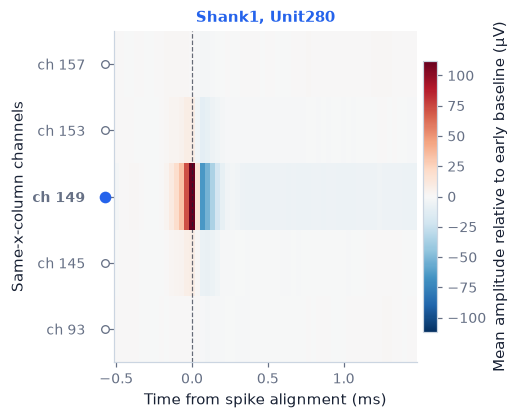

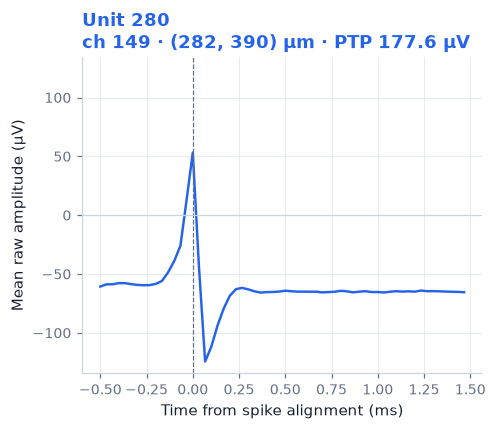

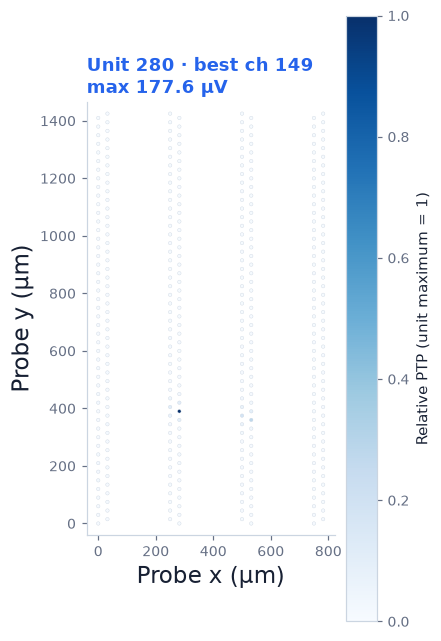

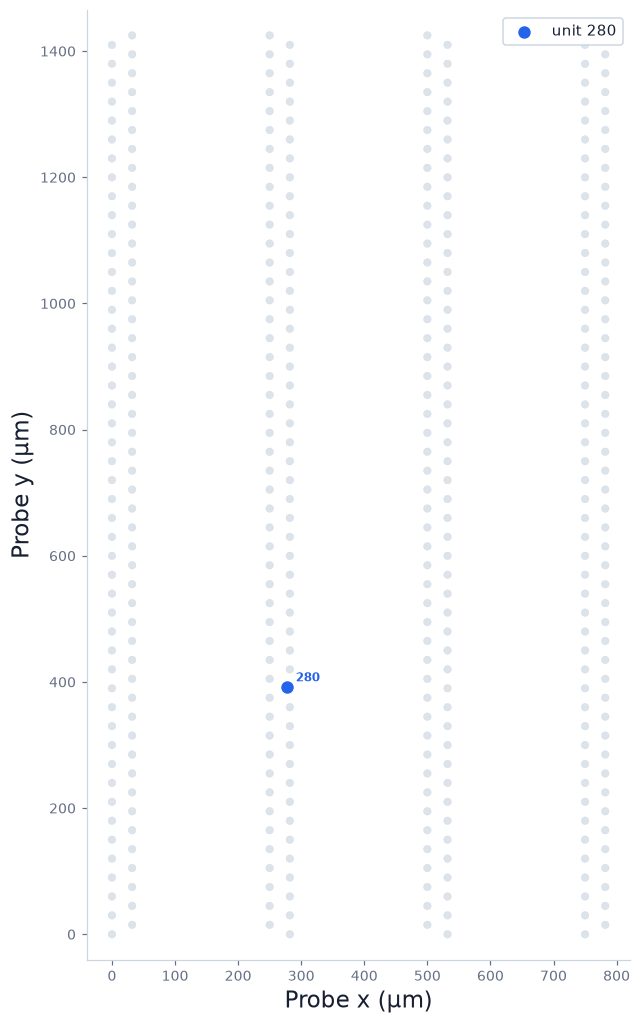

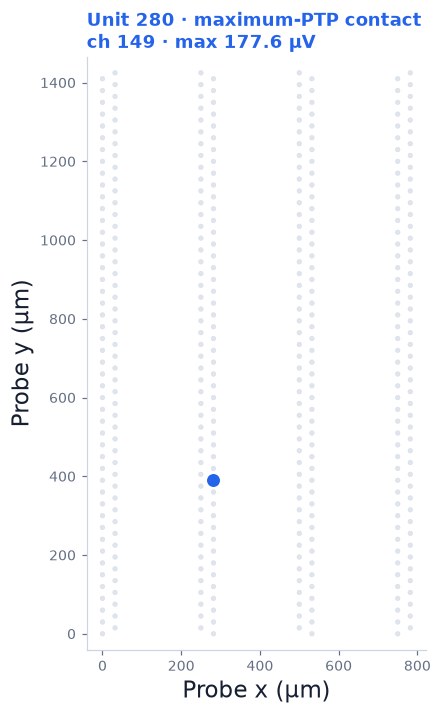

In [6]:
unit_plots.plot_local_average_heatmaps(local_channel_mode='same_x_column', )
unit_plots.plot_best_channel_averages()
unit_plots.plot_ptp_gradients()
unit_plots.plot_unit_locations(show_other_units=False)
max_contact_result = unit_plots.plot_max_ptp_contacts(
    layout='panels',
    show_other_units=False,
)

In [7]:
unit_plots